In [1]:

import importlib
import sys
if 'environment' in sys.modules:
    del sys.modules['environment']
import environment
from environment import WumpusWorldEnvironment
importlib.reload(environment)
from environment import WumpusWorldEnvironment

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim) 
        )

    def forward(self, x):
        return self.fc(x)

In [19]:

class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha  
        self.buffer = []
        self.pos = 0
        self.priorities = np.zeros((capacity,), dtype=np.float32)
    
    def push(self, state, action, reward, next_state, done):
        max_prio = self.priorities.max() if self.buffer else 1.0
        
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        """
        beta: 0.4 to 1.0
        """
        if len(self.buffer) == self.capacity:
            prios = self.priorities
        else:
            prios = self.priorities[:self.pos]
        probs = prios ** self.alpha
        probs /= probs.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()  
        
        
        states, actions, rewards, next_states, dones = zip(*samples)
        
        return (np.array(states, dtype=np.float32), 
                np.array(actions, dtype=np.int64), 
                np.array(rewards, dtype=np.float32), 
                np.array(next_states, dtype=np.float32), 
                np.array(dones, dtype=np.float32), 
                indices, 
                np.array(weights, dtype=np.float32))

    def update_priorities(self, batch_indices, batch_priorities):
        for idx, prio in zip(batch_indices, batch_priorities):
            self.priorities[idx] = prio + 1e-6

    def __len__(self):
        return len(self.buffer)

In [4]:
class PER_DQNAgent:
    def __init__(self, state_dim, action_dim, device="cpu", use_double=True):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.device = device
        self.use_double = use_double  # Part III 的核心开关
        
        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.memory = PrioritizedReplayBuffer(capacity=10000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.996
        self.epsilon_min = 0.01
        self.beta = 0.4  
        self.beta_increment = 0.001

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state_t)
            return q_values.argmax().item()

    def update(self, batch_size):
        if len(self.memory) < batch_size:
            return None
        
        states, actions, rewards, next_states, dones, indices, weights = \
            self.memory.sample(batch_size, beta=self.beta)
        
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)
        weights = torch.FloatTensor(weights).to(self.device)

    
        current_q = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            if self.use_double:
             
                next_actions = self.policy_net(next_states).max(1)[1].unsqueeze(1)
             
                next_q = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            else:
              
                next_q = self.target_net(next_states).max(1)[0]
                
            target_q = rewards + (1 - dones) * self.gamma * next_q

      
        td_errors = torch.abs(target_q - current_q.squeeze()).detach()
        self.memory.update_priorities(indices, td_errors.cpu().numpy())

    
        loss = (weights * (current_q.squeeze() - target_q).pow(2)).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.beta = min(1.0, self.beta + self.beta_increment) 
        
        return loss.item()

print("Double DQN (PER) Agent is ready.")


Double DQN (PER) Agent is ready.


In [5]:

def optimize_model(env, agent, num_episodes, batch_size, target_update_freq):
    total_rewards = []
    total_losses = []

    mode = "Double DQN" if getattr(agent, 'use_double', False) else "Vanilla DQN"
    print(f"Starting training using {mode}...")
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        episode_loss = []
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            agent.memory.push(state, action, reward, next_state, done)
            
            loss = agent.update(batch_size) 
            if loss is not None:
                episode_loss.append(loss)
                
            state = next_state
            episode_reward += reward
            
        if episode % target_update_freq == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())
            
        total_rewards.append(episode_reward)
        total_losses.append(np.mean(episode_loss) if episode_loss else 0)
        
        if (episode + 1) % 20 == 0:
            print(f"Episode {episode+1}/{num_episodes}, Reward: {episode_reward:.2f}, Epsilon: {agent.epsilon:.3f}")
        
    return total_rewards, total_losses

In [6]:
# Grid-world
import numpy as np
from environment import WumpusWorldEnvironment

env_grid = WumpusWorldEnvironment(observation_type='vector', action_type='discrete')

obs_sample, _ = env_grid.reset()

if isinstance(obs_sample, (int, np.integer)):
    grid_obs_dim = 1 
else:
    grid_obs_dim = len(obs_sample)

grid_action_dim = env_grid.action_space.n
print(f"Grid-world initialized. State dim: {grid_obs_dim}, Action dim: {grid_action_dim}")


Grid-world initialized. State dim: 2, Action dim: 4


Start training Grid World... State dim: 2, Active dim: 4
Starting training using Double DQN...
Episode 20/200, Reward: -115.00, Epsilon: 0.078
Episode 40/200, Reward: -101.00, Epsilon: 0.035
Episode 60/200, Reward: -101.00, Epsilon: 0.030
Episode 80/200, Reward: -101.00, Epsilon: 0.026
Episode 100/200, Reward: -101.00, Epsilon: 0.022
Episode 120/200, Reward: -101.00, Epsilon: 0.018
Episode 140/200, Reward: -101.00, Epsilon: 0.013
Episode 160/200, Reward: -101.00, Epsilon: 0.011
Episode 180/200, Reward: -101.00, Epsilon: 0.010
Episode 200/200, Reward: -101.00, Epsilon: 0.010


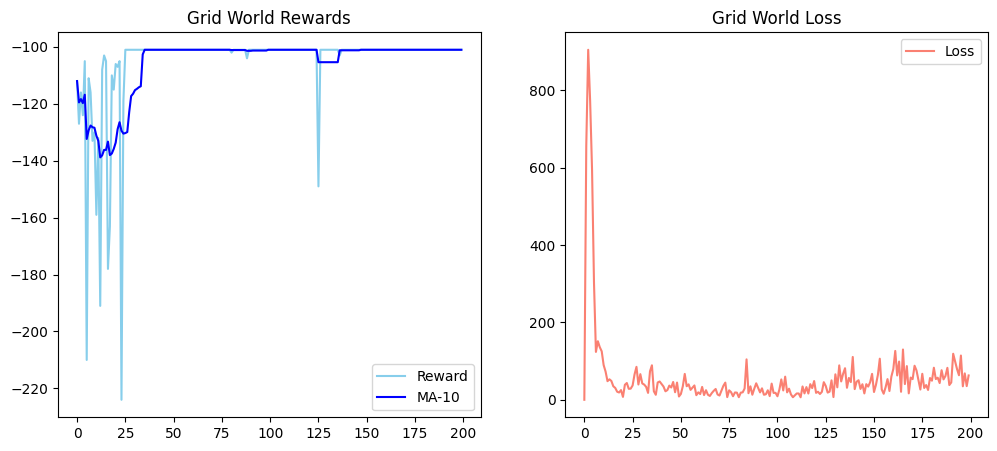

In [18]:
# Run Grid-world

try:
    state, _ = env_grid.reset()
except NameError:
    from environment import WumpusWorldEnvironment
    env_grid = WumpusWorldEnvironment(observation_type='vector', action_type='discrete')
    state, _ = env_grid.reset()

grid_obs_dim = np.prod(state.shape)
grid_action_dim = env_grid.action_space.n

agent_grid = PER_DQNAgent(
    state_dim=grid_obs_dim, 
    action_dim=grid_action_dim, 
    device=device
)

print(f"Start training Grid World... State dim: {grid_obs_dim}, Active dim: {grid_action_dim}")

grid_rewards, grid_losses = optimize_model(
    env=env_grid, 
    agent=agent_grid, 
    num_episodes=200, 
    batch_size=32, 
    target_update_freq=10
)

#plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(grid_rewards, color='skyblue', label='Reward')
if len(grid_rewards) > 10:
    ma = [np.mean(grid_rewards[max(0, i-10):i+1]) for i in range(len(grid_rewards))]
    plt.plot(ma, color='blue', label='MA-10')
plt.title("Grid World Rewards")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(grid_losses, color='salmon', label='Loss')
plt.title("Grid World Loss")
plt.legend()
plt.show()

In [8]:

env_cp = gym.make("CartPole-v1")

cp_state_dim = env_cp.observation_space.shape[0] 
cp_action_dim = env_cp.action_space.n        

print(f"CartPole dimension: State={cp_state_dim}, Action={cp_action_dim}")

agent_cp = PER_DQNAgent(state_dim=cp_state_dim, action_dim=cp_action_dim, device=device)

print("Start training CartPole-v1 (PER-DQN)...")
cp_rewards, cp_losses = optimize_model(env_cp, agent_cp, num_episodes=400, batch_size=64, target_update_freq=15)

env_cp.close()
print("CartPole training over！")

CartPole dimension: State=4, Action=2
Start training CartPole-v1 (PER-DQN)...
Starting training using Double DQN...
Episode 20/400, Reward: 39.00, Epsilon: 0.209
Episode 40/400, Reward: 12.00, Epsilon: 0.089
Episode 60/400, Reward: 152.00, Epsilon: 0.014
Episode 80/400, Reward: 172.00, Epsilon: 0.010
Episode 100/400, Reward: 197.00, Epsilon: 0.010
Episode 120/400, Reward: 140.00, Epsilon: 0.010
Episode 140/400, Reward: 138.00, Epsilon: 0.010
Episode 160/400, Reward: 136.00, Epsilon: 0.010
Episode 180/400, Reward: 133.00, Epsilon: 0.010
Episode 200/400, Reward: 145.00, Epsilon: 0.010
Episode 220/400, Reward: 123.00, Epsilon: 0.010
Episode 240/400, Reward: 129.00, Epsilon: 0.010
Episode 260/400, Reward: 172.00, Epsilon: 0.010
Episode 280/400, Reward: 209.00, Epsilon: 0.010
Episode 300/400, Reward: 77.00, Epsilon: 0.010
Episode 320/400, Reward: 162.00, Epsilon: 0.010
Episode 340/400, Reward: 215.00, Epsilon: 0.010
Episode 360/400, Reward: 168.00, Epsilon: 0.010
Episode 380/400, Reward: 23

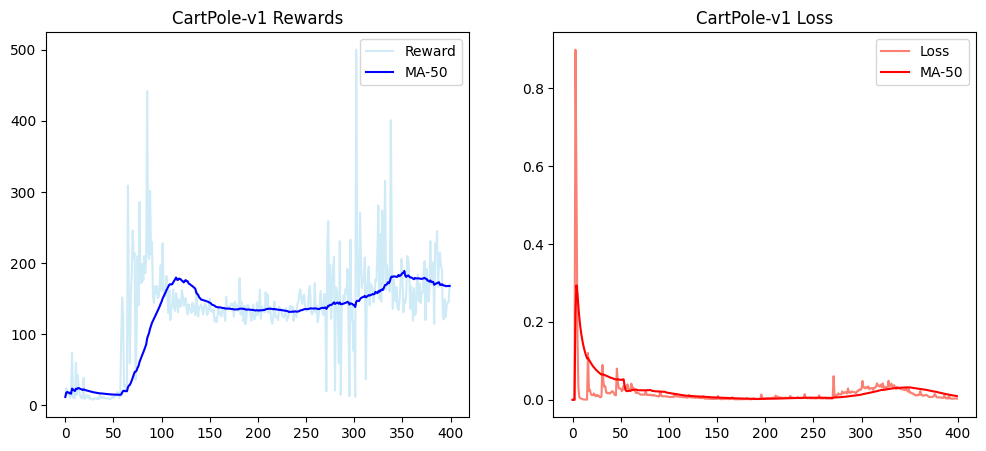

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cp_rewards, color='skyblue', label='Reward', alpha=0.4)
if len(cp_rewards) > 50:
    ma = [np.mean(cp_rewards[max(0, i-50):i+1]) for i in range(len(cp_rewards))]
    plt.plot(ma, color='blue', label='MA-50')
plt.title("CartPole-v1 Rewards")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cp_losses, color='salmon', label='Loss')
if len(cp_losses) > 50:
    ma_loss = [np.mean(cp_losses[max(0, i-50):i+1]) for i in range(len(cp_losses))]
    plt.plot(ma_loss, color='red', label='MA-50')
plt.title("CartPole-v1 Loss")
plt.legend()
plt.show()

In [14]:

env_acro = gym.make("Acrobot-v1")

acro_s_dim = env_acro.observation_space.shape[0] 
acro_a_dim = env_acro.action_space.n 

print(f"Acrobot dimention: State={acro_s_dim}, Action={acro_a_dim}")

agent_acro = PER_DQNAgent(state_dim=acro_s_dim, action_dim=acro_a_dim, device=device)

print("Start training Acrobot-v1 (PER-DQN)...")

ac_rewards, ac_losses = optimize_model(env_cp, agent_cp, num_episodes=600, batch_size=64, target_update_freq=15)

env_acro.close()

Acrobot dimention: State=6, Action=3
Start training Acrobot-v1 (PER-DQN)...
Starting training using Double DQN...
Episode 20/600, Reward: 281.00, Epsilon: 0.010
Episode 40/600, Reward: 105.00, Epsilon: 0.010
Episode 60/600, Reward: 388.00, Epsilon: 0.010
Episode 80/600, Reward: 247.00, Epsilon: 0.010
Episode 100/600, Reward: 349.00, Epsilon: 0.010
Episode 120/600, Reward: 470.00, Epsilon: 0.010
Episode 140/600, Reward: 207.00, Epsilon: 0.010
Episode 160/600, Reward: 415.00, Epsilon: 0.010
Episode 180/600, Reward: 287.00, Epsilon: 0.010
Episode 200/600, Reward: 311.00, Epsilon: 0.010
Episode 220/600, Reward: 140.00, Epsilon: 0.010
Episode 240/600, Reward: 275.00, Epsilon: 0.010
Episode 260/600, Reward: 249.00, Epsilon: 0.010
Episode 280/600, Reward: 227.00, Epsilon: 0.010
Episode 300/600, Reward: 435.00, Epsilon: 0.010
Episode 320/600, Reward: 189.00, Epsilon: 0.010
Episode 340/600, Reward: 293.00, Epsilon: 0.010
Episode 360/600, Reward: 151.00, Epsilon: 0.010
Episode 380/600, Reward: 5

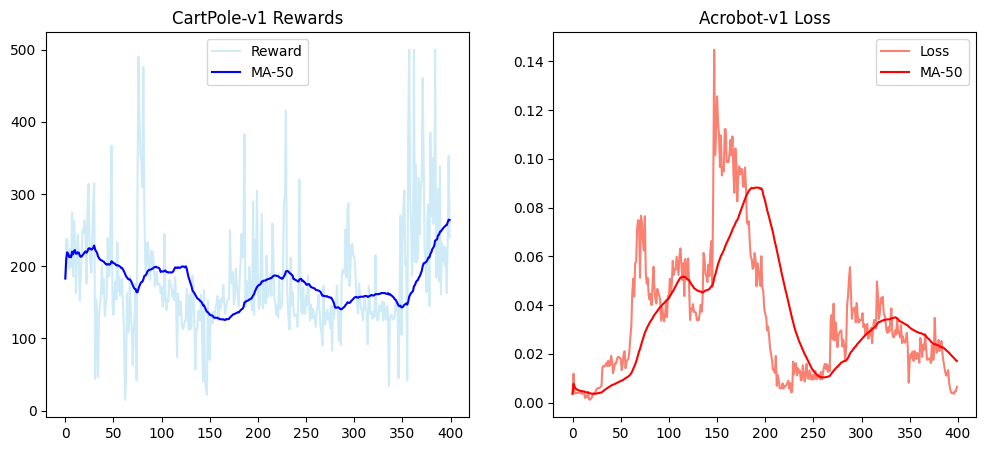

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ac_rewards, color='skyblue', label='Reward', alpha=0.4)
if len(ac_rewards) > 50:
    ma = [np.mean(ac_rewards[max(0, i-50):i+1]) for i in range(len(ac_rewards))]
    plt.plot(ma, color='blue', label='MA-50')
plt.title("CartPole-v1 Rewards")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ac_losses, color='salmon', label='Loss')
if len(ac_losses) > 50:
    ma_loss = [np.mean(ac_losses[max(0, i-50):i+1]) for i in range(len(ac_losses))]
    plt.plot(ma_loss, color='red', label='MA-50')
plt.title("Acrobot-v1 Loss")
plt.legend()
plt.show()